In [ ]:
# 1. 입력 데이터 준비
# 각 응력 조건에 대해 [실제 작용한 횟수(n), 그 응력에서의 한계 수명(N)]을 리스트로 묶음
# 조건 1: 300 MPa에서 5만 번 작용 (한계 수명 10만 번)
# 조건 2: 200 MPa에서 20만 번 작용 (한계 수명 100만 번)
fatigue_data = [
    {"stress": 300, "applied_cycles_n": 50000, "life_limit_N": 100000},
    {"stress": 200, "applied_cycles_n": 200000, "life_limit_N": 1000000}
]

# 2. 누적 손상도(Damage, D) 계산
total_damage = 0.0

print("=== 누적 피로 손상(Miner's Rule) 계산 ===")
for i, data in enumerate(fatigue_data):
    n = data["applied_cycles_n"]
    N = data["life_limit_N"]

    # 해당 응력이 기여한 손상 비율 계산
    damage_fraction = n / N
    total_damage += damage_fraction

    print(f"조건 {i+1} ({data['stress']} MPa): 손상 기여도 = {damage_fraction:.2f} ({damage_fraction*100:.0f}%)")

# 3. 파괴 여부 판정 및 결과 출력
print("-" * 40)
print(f"총 누적 피로 손상도 (D) : {total_damage:.3f}")

if total_damage >= 1.0:
    print("판정: D >= 1.0 이므로 부품이 **피로 파괴**됩니다! (재설계 필요)")
else:
    remaining_life_pct = (1.0 - total_damage) * 100
    print(f"판정: D < 1.0 이므로 안전합니다. (잔여 수명: 약 {remaining_life_pct:.1f}%)")


=== 누적 피로 손상(Miner's Rule) 계산 ===
조건 1 (300 MPa): 손상 기여도 = 0.50 (50%)
조건 2 (200 MPa): 손상 기여도 = 0.20 (20%)
----------------------------------------
총 누적 피로 손상도 (D) : 0.700
판정: D < 1.0 이므로 안전합니다. (잔여 수명: 약 30.0%)


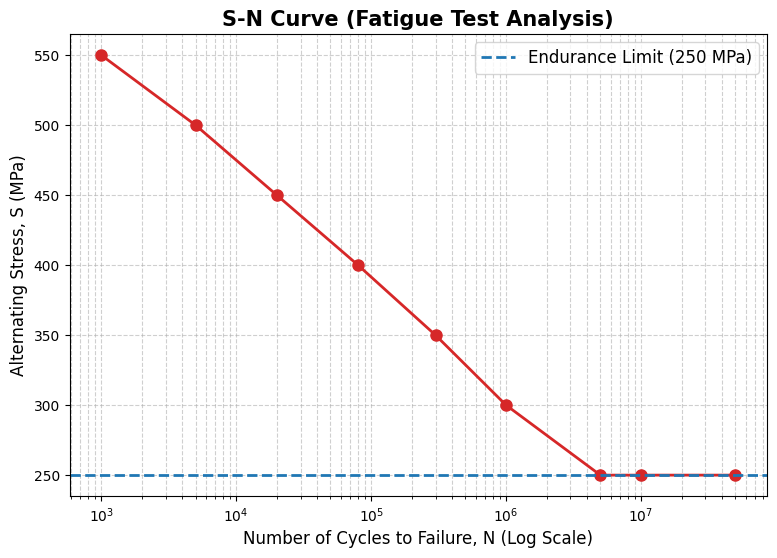

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 방대한 실험 데이터 불러오기 (실제 환경에서는 csv 파일을 불러옵니다)
# 예시: df = pd.read_csv('fatigue_test_results.csv')
# 여기서는 코랩에서 바로 실행되도록 가상의 데이터프레임을 생성합니다.
data = {
    'Stress_MPa': [550, 500, 450, 400, 350, 300, 250, 250, 250],
    'Cycles_N': [10**3, 5*10**3, 2*10**4, 8*10**4, 3*10**5, 10**6, 5*10**6, 10**7, 5*10**7]
}
df = pd.DataFrame(data)

# 2. S-N 선도 시각화 (Matplotlib 활용)
plt.figure(figsize=(9, 6))

# 데이터를 점과 선으로 연결하여 그래프 작성
plt.plot(df['Cycles_N'], df['Stress_MPa'], marker='o', linestyle='-', color='#d62728', linewidth=2, markersize=8)

# 피로 파괴의 핵심! X축(수명)을 로그 스케일로 변환
plt.xscale('log')

# 특정 응력 이하에서는 파괴되지 않는 '피로 한도(Endurance Limit)' 기준선 추가
endurance_limit = 250
plt.axhline(y=endurance_limit, color='#1f77b4', linestyle='--', linewidth=2, label=f'Endurance Limit ({endurance_limit} MPa)')

# 그래프 꾸미기
plt.title('S-N Curve (Fatigue Test Analysis)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Cycles to Failure, N (Log Scale)', fontsize=12)
plt.ylabel('Alternating Stress, S (MPa)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=12)

plt.show()